<a href="https://colab.research.google.com/github/Abhii-00/ai_ml_lab/blob/main/decision_tree_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Titanic_Cleaned.csv to Titanic_Cleaned (1).csv


In [5]:
df = pd.read_csv("Titanic_Cleaned.csv")

In [7]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0          1.0         0       3   
1          2.0         1       1   
2          3.0         1       3   
3          4.0         1       1   
4          5.0         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare    Cabin Embarked  FamilySize  
0      0         A/5 21171   7.2500  Unknown        S           2  
1      0          PC 17599  71.2833      C85        C           2  
2      0  STON/O2. 3101282   7.9250  Unknown        S           1  
3      0            113803  53.1000     C123    

In [8]:
df = pd.get_dummies(
    df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)
print(df.head())

   PassengerId  Survived  Pclass  \
0          1.0         0       3   
1          2.0         1       1   
2          3.0         1       3   
3          4.0         1       1   
4          5.0         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare    Cabin  FamilySize  Sex_male  Embarked_Q  \
0         A/5 21171   7.2500  Unknown           2      True       False   
1          PC 17599  71.2833      C85           2     False       False   
2  STON/O2. 3101282   7.9250  Unknown           1     False       False   
3            113803  53.10

In [9]:
df = df.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Cabin']
)
print(df.columns)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'Sex_male', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [10]:
X = df.drop('Survived', axis=1)
y = df['Survived']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Pclass   Age  SibSp  Parch     Fare  FamilySize  Sex_male  Embarked_Q  \
0       3  22.0      1      0   7.2500           2      True       False   
1       1  38.0      1      0  71.2833           2     False       False   
2       3  26.0      0      0   7.9250           1     False       False   
3       1  35.0      1      0  53.1000           2     False       False   
4       3  35.0      0      0   8.0500           1      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  

Target:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [13]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
y_pred = rf_model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8100558659217877
Accuracy (%): 81.00558659217877


In [16]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[95 15]
 [19 50]]


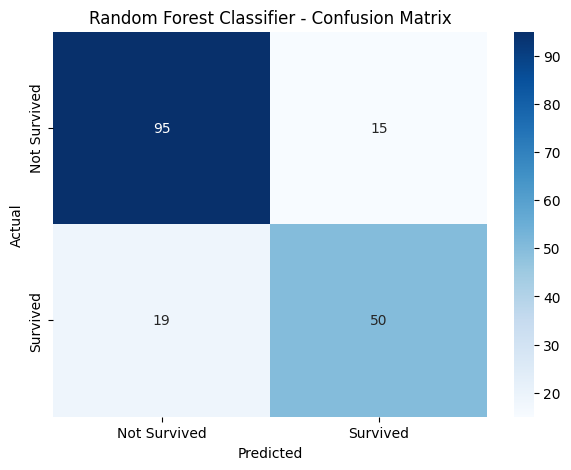

In [18]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Classifier - Confusion Matrix")

plt.show()

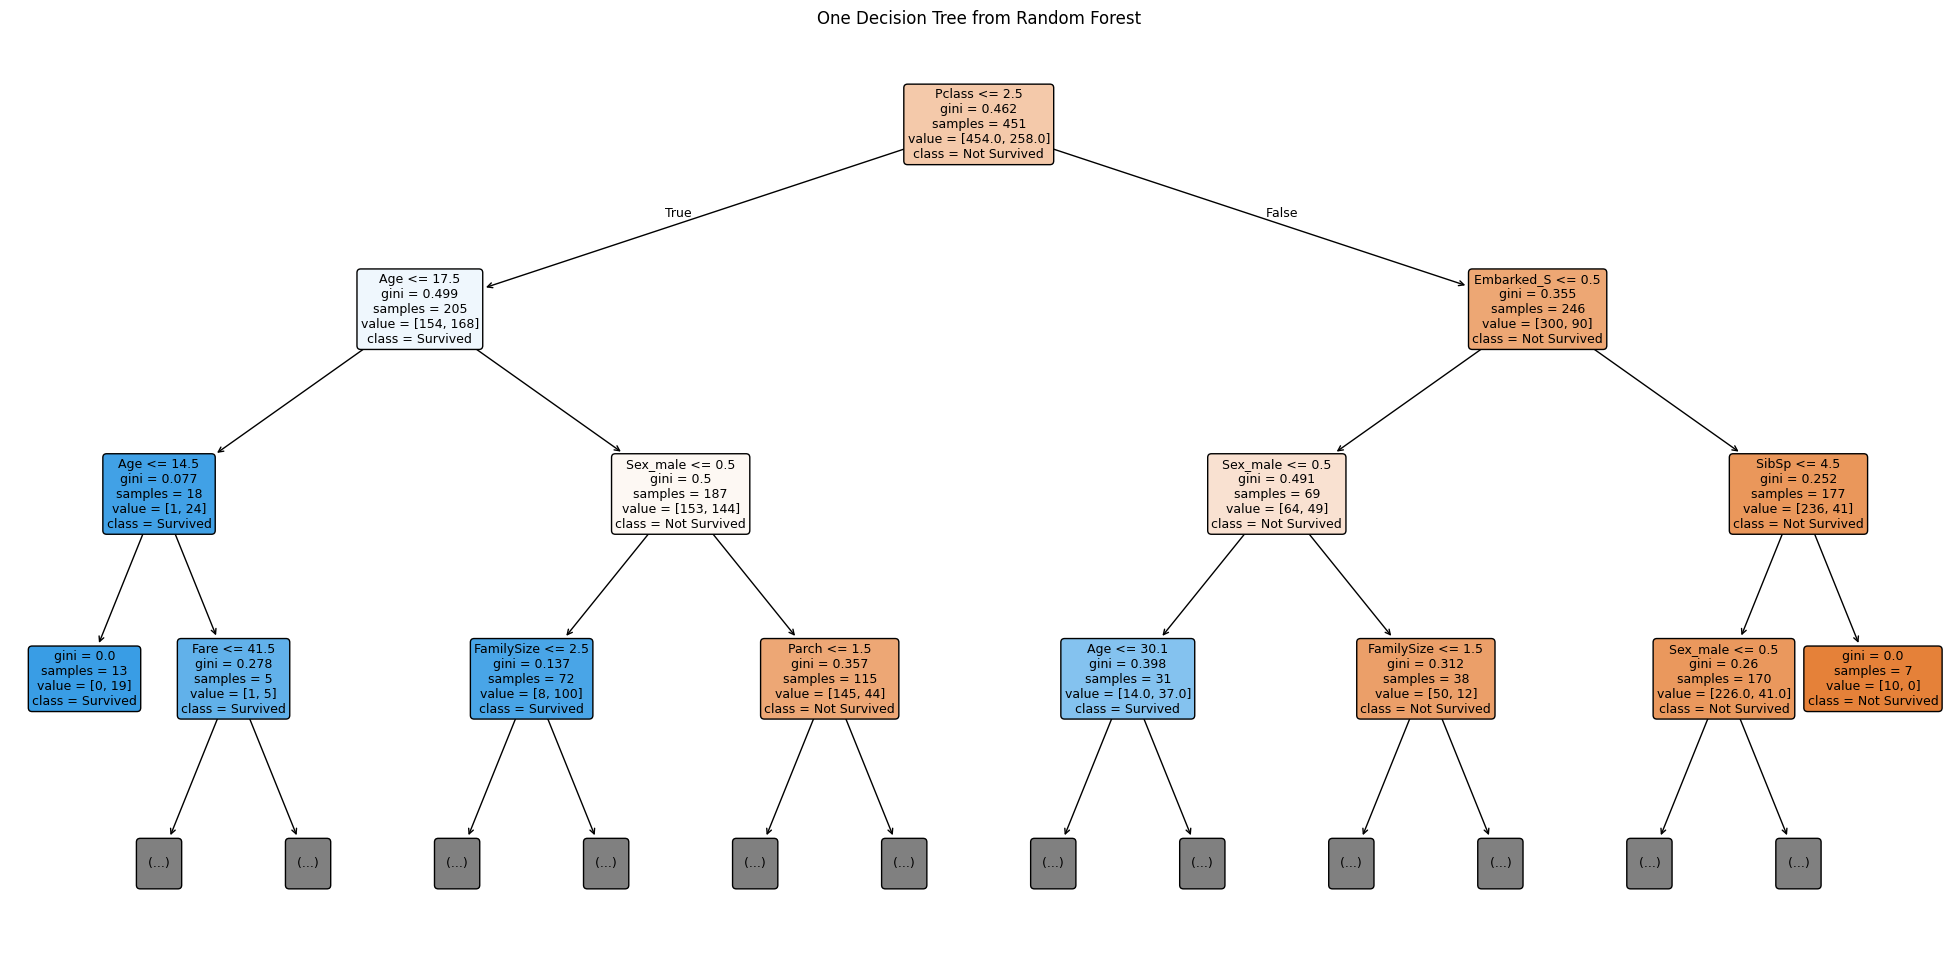

In [19]:
plt.figure(figsize=(25, 12))

plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("One Decision Tree from Random Forest")
plt.show()

feature importance

In [20]:
feature_importance = rf_model.feature_importances_

for feature, importance in zip(X.columns, feature_importance):
    print(feature, ":", importance)

Pclass : 0.08735709778031508
Age : 0.24099609876257055
SibSp : 0.03214415766092339
Parch : 0.025214805232186825
Fare : 0.2710093086759601
FamilySize : 0.048918030162382754
Sex_male : 0.26112366300739004
Embarked_Q : 0.008010823933283824
Embarked_S : 0.02522601478498752


feature importance visualization

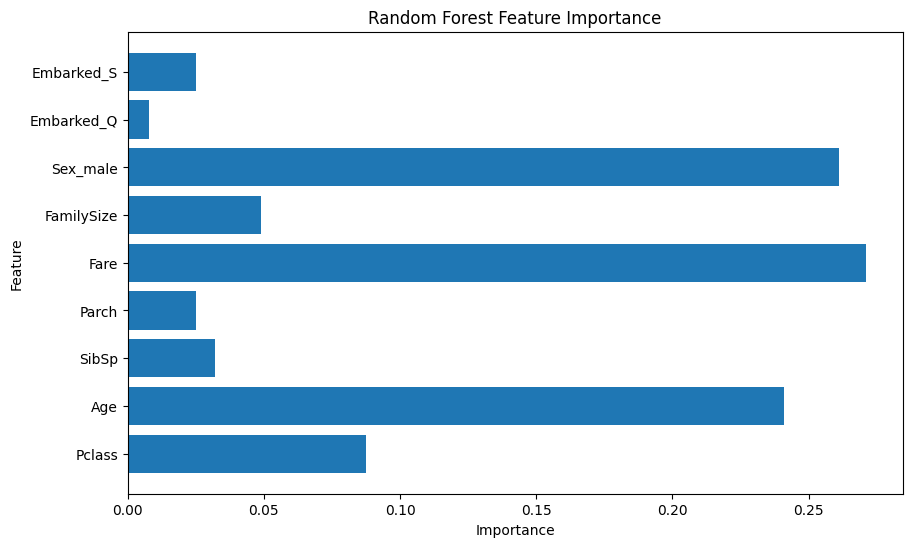

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    X.columns,
    rf_model.feature_importances_
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()